## Imports

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
if not os.path.exists("models"):
    os.makedirs("models")

## Utils

In [ ]:
def build_discriminator():
    img_input = layers.Input(shape=(28, 28, 1), name="image_input")
    label_input = layers.Input(shape=(1,), name="label_input")
    
    # Embed the label and reshape it into a 28x28x1 spatial map
    label_embedding = layers.Embedding(input_dim=10, output_dim=50)(label_input)
    label_dense = layers.Dense(28 * 28 * 1)(label_embedding)
    label_reshape = layers.Reshape((28, 28, 1))(label_dense)
    
    # 28x28x2
    merged = layers.Concatenate()([img_input, label_reshape])
    
    x = layers.Conv2D(64, (5, 5), strides=(2, 2), padding="same")(merged)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv2D(128, (5, 5), strides=(2, 2), padding="same")(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Flatten()(x)
    
    # raw logits for numerical stability 
    out = layers.Dense(1)(x)
    
    return models.Model(inputs=[img_input, label_input], outputs=out, name="Discriminator")

In [4]:
def build_generator(latent_dim):
    noise_input = layers.Input(shape=(latent_dim,), name="noise_input")
    label_input = layers.Input(shape=(1,), name="label_input")
    
    # Embed label and concatenate with the noise vector
    label_embedding = layers.Embedding(input_dim=10, output_dim=50)(label_input)
    label_embedding = layers.Flatten()(label_embedding)
    merged = layers.Concatenate()([noise_input, label_embedding])
    
    x = layers.Dense(7 * 7 * 256, use_bias=False)(merged)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Reshape((7, 7, 256))(x)
    
    x = layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    x = layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    out = layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding="same", use_bias=False, activation="tanh")(x)
    
    return models.Model(inputs=[noise_input, label_input], outputs=out, name="Generator")

In [ ]:
class CGAN(models.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super(CGAN, self).__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(CGAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        self.d_loss_metric = tf.keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = tf.keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, data):
        real_images, labels = data
        batch_size = tf.shape(real_images)[0]

        # Train the Discriminator
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        generated_images = self.generator([random_latent_vectors, labels])

        combined_images = tf.concat([generated_images, real_images], axis=0)
        combined_labels = tf.concat([labels, labels], axis=0) 

        # Labels: 0 for fake, 1 for real
        d_labels = tf.concat([tf.zeros((batch_size, 1)), tf.ones((batch_size, 1))], axis=0)
        d_labels += 0.05 * tf.random.uniform(tf.shape(d_labels))

        with tf.GradientTape() as tape:
            predictions = self.discriminator([combined_images, combined_labels])
            d_loss = self.loss_fn(d_labels, predictions)

        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

        # Train the Generator
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        misleading_labels = tf.ones((batch_size, 1))

        with tf.GradientTape() as tape:
            fake_images = self.generator([random_latent_vectors, labels])
            predictions = self.discriminator([fake_images, labels])
            g_loss = self.loss_fn(misleading_labels, predictions)

        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)

        return {
            "d_loss": self.d_loss_metric.result(),
            "g_loss": self.g_loss_metric.result(),
        }

In [ ]:
def test_and_predict(generator, discriminator, latent_dim, num_images=16):
    print("\nPredictions")
    
    class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    
    random_latent_vectors = tf.random.normal(shape=(num_images, latent_dim))    
    random_labels = tf.random.uniform(shape=(num_images, 1), minval=0, maxval=10, dtype=tf.int32)
    
    generated_images = generator([random_latent_vectors, random_labels], training=False)
    
    raw_logits = discriminator([generated_images, random_labels], training=False)
    discriminator_scores = tf.nn.sigmoid(raw_logits)
    
    generated_images = (generated_images + 1.0) / 2.0
    
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    fig.suptitle('Conditional GAN: Generated Images & Discriminator Scores\n(>0.5 = Discriminator Fooled)', fontsize=16)
    
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(generated_images[i, :, :, 0], cmap='gray')
        
        score = discriminator_scores[i][0].numpy()
        label_idx = random_labels[i][0].numpy()
        item_name = class_names[label_idx]
        
        color = 'green' if score > 0.5 else 'red'
        
        ax.set_title(f"{item_name}\nProb: {score:.3f}", color=color)
        ax.axis('off')
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

## Dataset

In [ ]:
(X_train, y_train), (_, _) = tf.keras.datasets.fashion_mnist.load_data()
X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5
X_train = np.expand_dims(X_train, axis=-1)

BATCH_SIZE = 256
LATENT_DIM = 100

# Include labels in the dataset tuples
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(60000).batch(BATCH_SIZE)

2026-05-12 11:52:54.190643: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-05-12 11:52:54.190670: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-05-12 11:52:54.190677: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2026-05-12 11:52:54.190722: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-12 11:52:54.190744: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Training

Epoch 1/30


/Users/dgutu/Programming/University/Neural-Networks/.venv/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
2026-05-12 11:52:55.318892: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


235/235 ━━━━━━━━━━━━━━━━━━━━ 34s 126ms/step - d_loss: 0.5878 - g_loss: 0.8910
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 123ms/step - d_loss: 0.5920 - g_loss: 1.0400
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 124ms/step - d_loss: 0.5549 - g_loss: 1.0371
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 122ms/step - d_loss: 0.5820 - g_loss: 0.9882
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - d_loss: 0.6208 - g_loss: 0.8800

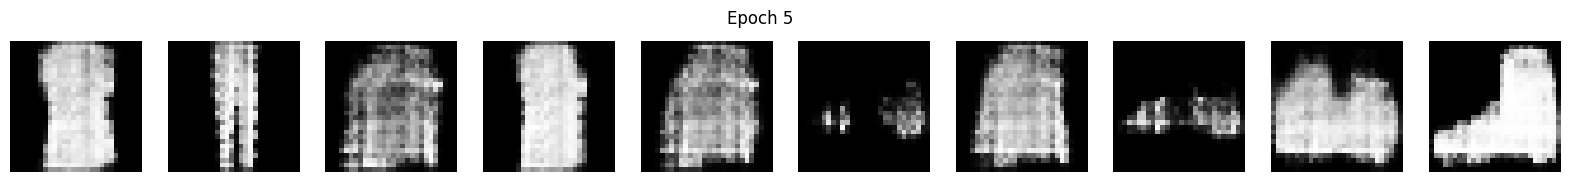

235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 127ms/step - d_loss: 0.6189 - g_loss: 0.8766
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 124ms/step - d_loss: 0.6115 - g_loss: 0.8780
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 123ms/step - d_loss: 0.6081 - g_loss: 0.8632
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 123ms/step - d_loss: 0.6137 - g_loss: 0.8396
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 125ms/step - d_loss: 0.6291 - g_loss: 0.8105
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 0.6468 - g_loss: 0.7815

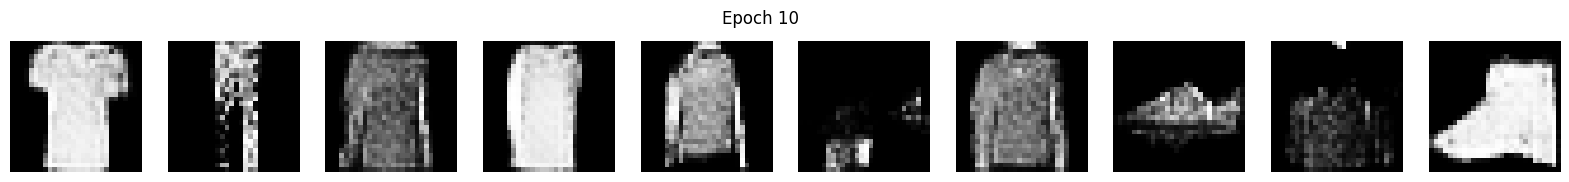

235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 124ms/step - d_loss: 0.6448 - g_loss: 0.7721
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 126ms/step - d_loss: 0.6460 - g_loss: 0.7565
Epoch 12/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 125ms/step - d_loss: 0.6585 - g_loss: 0.7275
Epoch 13/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 125ms/step - d_loss: 0.6565 - g_loss: 0.7345
Epoch 14/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 126ms/step - d_loss: 0.6581 - g_loss: 0.7341
Epoch 15/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - d_loss: 0.6605 - g_loss: 0.7330

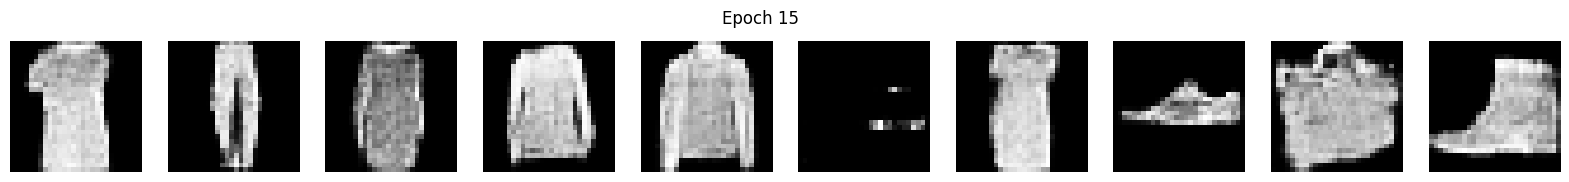

235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 126ms/step - d_loss: 0.6579 - g_loss: 0.7383
Epoch 16/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 128ms/step - d_loss: 0.6608 - g_loss: 0.7335
Epoch 17/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 127ms/step - d_loss: 0.6646 - g_loss: 0.7228
Epoch 18/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 124ms/step - d_loss: 0.6658 - g_loss: 0.7275
Epoch 19/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 126ms/step - d_loss: 0.6717 - g_loss: 0.7129
Epoch 20/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - d_loss: 0.6713 - g_loss: 0.7082

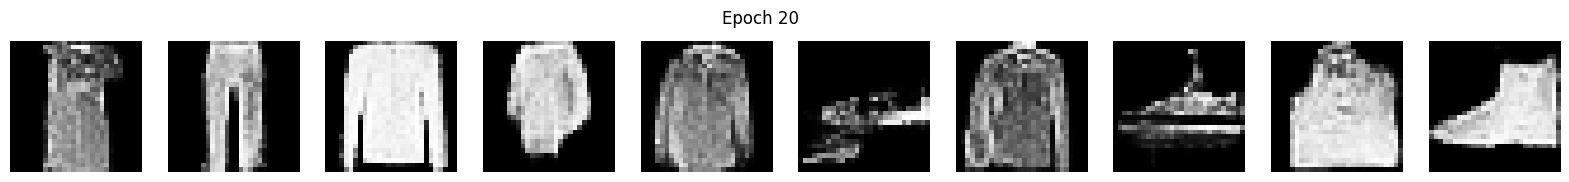

235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 127ms/step - d_loss: 0.6712 - g_loss: 0.7077
Epoch 21/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 127ms/step - d_loss: 0.6761 - g_loss: 0.6995
Epoch 22/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 126ms/step - d_loss: 0.6780 - g_loss: 0.6970
Epoch 23/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 125ms/step - d_loss: 0.6793 - g_loss: 0.6941
Epoch 24/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 127ms/step - d_loss: 0.6801 - g_loss: 0.6962
Epoch 25/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - d_loss: 0.6792 - g_loss: 0.6959

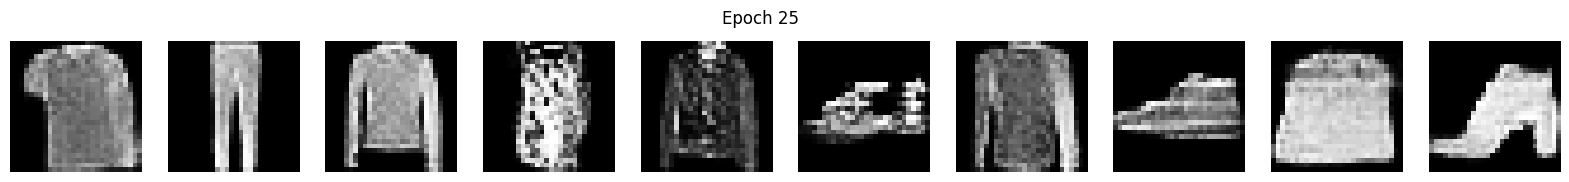

235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 128ms/step - d_loss: 0.6798 - g_loss: 0.6971
Epoch 26/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 128ms/step - d_loss: 0.6783 - g_loss: 0.6981
Epoch 27/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 129ms/step - d_loss: 0.6793 - g_loss: 0.6929
Epoch 28/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 128ms/step - d_loss: 0.6801 - g_loss: 0.7109
Epoch 29/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 125ms/step - d_loss: 0.6783 - g_loss: 0.6937
Epoch 30/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - d_loss: 0.6782 - g_loss: 0.6892

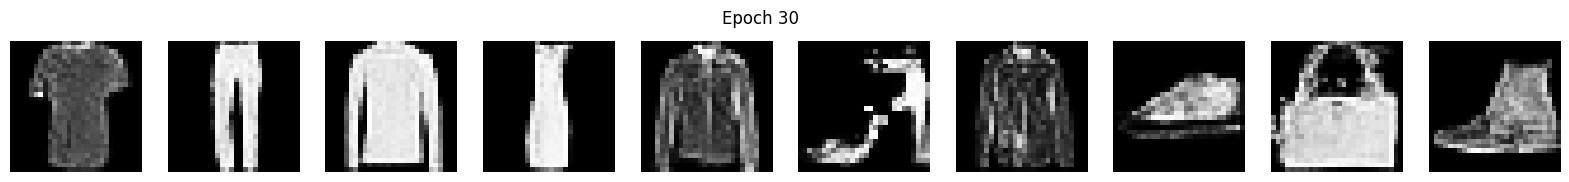

235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 125ms/step - d_loss: 0.6792 - g_loss: 0.6936


In [ ]:
class SaveModelAndImages(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            os.makedirs("models", exist_ok=True)
            self.model.generator.save(f"models/generator_epoch_{epoch+1}.h5")
        if (epoch + 1) % 5 == 0:
            noise = tf.random.normal([10, LATENT_DIM])
            labels = tf.constant([[i] for i in range(10)])
            gen_images = self.model.generator([noise, labels], training=False)
            
            fig, axes = plt.subplots(1, 10, figsize=(20, 2))
            for i in range(10):
                axes[i].imshow(gen_images[i, :, :, 0] * 127.5 + 127.5, cmap="gray")
                axes[i].axis("off")
            plt.suptitle(f"Epoch {epoch+1}")
            plt.show()

discriminator = build_discriminator()
generator = build_generator(LATENT_DIM)
cgan = CGAN(discriminator=discriminator, generator=generator, latent_dim=LATENT_DIM)

cgan.compile(
    d_optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    g_optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=True),
)

EPOCHS = 30
cgan.fit(dataset, epochs=EPOCHS, callbacks=[SaveModelAndImages()])
generator.save("models/final_generator_model.keras")


Predictions


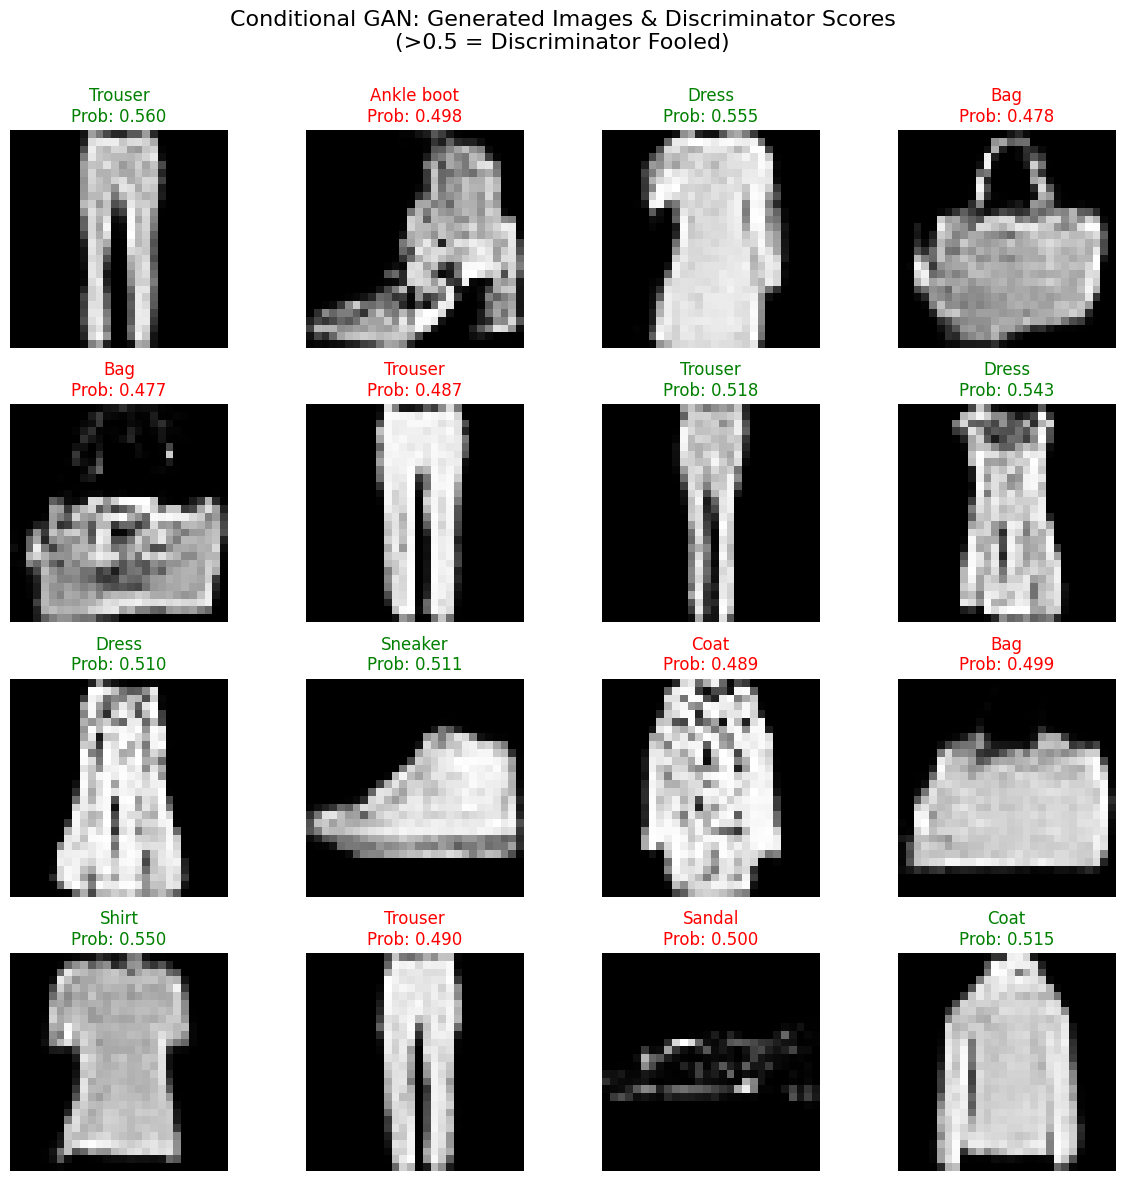

In [13]:
test_and_predict(generator, discriminator, LATENT_DIM)